# Legnini - Gene rank analysis

Evaluate attention matrix from trained regression model.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import scanpy as sc
import squidpy as sq
import numpy as np
import pandas as pd

## plotting imports
import matplotlib.pyplot as plt
import seaborn as sns

## InterScale imports
import InterScale as interscale
from InterScale.config import load_config
from InterScale.tl import prepare_geome_dataset, check_and_update_cfg
from InterScale.geome_dataloader import GraphAnnDataModule
from InterScale.evaluation.gene_rank_analysis import gene_rank_analysis, gene_rank_condition_comparison
from InterScale.tl import prepare_a2d_dataset
from InterScale.evaluation import scale_cls_by_sample

from pathlib import Path
import torch

## Set up paths

Check which cluster by testing for distinctive directories then set:

- `BASE_DIR_REPO`: path to github repo (InterScale code)
- `BASE_DIR_PROJECT`: path to project folder, where results, models, etc are stored

In [41]:
import os

# LRZ home
if os.path.exists("/dss/dsshome1/05/di93tig"):
    print('LRZ cluster')
    CLUSTER = 'LRZ'
    BASE_DIR_REPO = "/dss/dsshome1/05/di93tig/1_projects" 
    BASE_DIR_PROJECT = "/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale"
elif os.path.exists("/home/icb/francesca.drummer/"):
    print('HPC cluster')
    CLUSTER = 'HPC'
    BASE_DIR_REPO = "/home/icb/francesca.drummer/1-Projects/"
    BASE_DIR_PROJECT = ""
else:
    print('unkown')
    CLUSTER = 'unknown'

DATA = "legnini23"

LRZ cluster


In [42]:
# path on ICB or LRZ cluster to InterScale_reproducibility folder
CFG_CLASS = os.path.join(BASE_DIR_REPO, f"GT-long-range-niches/src/config_files/{DATA}/legnini23_regr_node_DualCombined_genes.yaml")
RESULTS_DIR = os.path.join(BASE_DIR_PROJECT, f"results/{DATA}/")
FIGURE_DIR = os.path.join(BASE_DIR_REPO, f"InterScale_reproducibility/figures/{DATA}")

In [43]:
path = os.path.join("/home", "user", "documents", "/etc", "config.txt")
path

'/etc/config.txt'

In [44]:
import sys
from pathlib import Path

# Add project root to path (go up 2 levels from notebook location)
project_root = Path(f'{BASE_DIR_REPO}/InterScale_reproducibility')
sys.path.insert(0, str(project_root))

from src.utils import set_full_reproducibility
from src.wandb import Wandb_evaluation

## Global parameters

Fix the seeds across all imports.

In [45]:
set_full_reproducibility()

## Figure settings

In [49]:
import yaml
import matplotlib.pyplot as plt

config_path = os.path.join(BASE_DIR_REPO, "InterScale_reproducibility/figures/config.yml")

with open(config_path, "r") as f:
    config = yaml.safe_load(f)

PALETTE = config["palettes"]["continuous"]
CELL_TYPE_COLORS = config["palettes"][DATA]
CONDITION_COLORS = config["palettes"][DATA]["condition"]

In [50]:
from figures.scripts.plots import Plotting

plotting = Plotting(config_path)
plotting._setup_plotting_params()

In [51]:
CONDITION_KEY = 'condition'

## Load config and model

In [11]:
adata = sc.read_h5ad(os.path.join(BASE_DIR_PROJECT, "data", f"{DATA}.h5ad"))
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw'

In [12]:
np.unique(adata.obs['condition'])

array(['Ctrl', 'SHH'], dtype=object)

### Local source

In [13]:
cfg = load_config(CFG_CLASS)

In [14]:
assert BASE_DIR_PROJECT in cfg.model.save 
assert BASE_DIR_PROJECT in cfg.dataset.h5ad_data

In [15]:
# assign cell type colors
color_list = [CONDITION_COLORS[ct] for ct in adata.obs[CONDITION_KEY].cat.categories]
adata.uns[f'{CONDITION_COLORS}_colors'] = color_list

In [16]:
#interscale.model.LocalModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs =  cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label, view_registry = False)
#local_model = interscale.model.LocalModel.load(RESULTS_DIR, adata, cfg, local_component = True, global_component = False, wandb_save = True)
interscale.model.CombinedModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs =  cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label, view_registry = False)
combined_model = interscale.model.CombinedModel.load(RESULTS_DIR, adata, cfg, local_component = True, global_component = True, wandb_save = True)

Loading model from /dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale/results/legnini23/dual_legnini23_regr_node_44_GCN_self-attn-transformer_model.pt
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


## Inference: get model output 

In [17]:
slide_ids = list(config["slide_examples"][DATA].values())

In [18]:
sub_adata = adata[adata.obs['sample'].isin(slide_ids)]

In [19]:
result = combined_model.get_model_output(sub_adata, prefix = 'combined')

INFO     Received view of anndata, making copy.                                                                    
Load GEX from .layers/log1p_norm
call new


In [20]:
result

AnnData object with n_obs × n_vars = 3763 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', '_scvi_sample_key_0', '_scvi_group_label', 'combined_cls_horizontal', 'combined_cls_vertical'
    var: 'gene_ids', 'feature_types'
    uns: "{'Ctrl': '#005F73', 'SHH': '#EE9B00'}_colors", '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial', 'combined_local_emb', 'combined_global_emb', 'combined_attn_matrix'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw', 'combined_y_pred_local', 'combined_y_pred_global'

In [26]:
result_complete = combined_model.get_model_output(adata, prefix = 'combined')

Load GEX from .layers/log1p_norm
call new


In [38]:
assert result_complete.X[:10, :10].dtype == np.float32

### Condition-based gene-rank analysis

Top 5 genes for combined_y_pred_local model:
        gene        r2    r2_log  r2_rank
40     ISL1  0.039470  0.038711     88.0
5       ARC  0.024043  0.023758     87.0
53   NKX2.1  0.000000  0.000000     85.5
87    TREM2  0.000000  0.000000     85.5
51  NEUROD1 -0.015915 -0.016043     84.0
Top 5 genes for combined_y_pred_global model:
       gene        r2    r2_log  r2_rank
61   OLIG2  0.021025  0.020807     88.0
53  NKX2.1  0.000000  0.000000     86.5
87   TREM2  0.000000  0.000000     86.5
73     SHH -0.030417 -0.030889     85.0
54  NKX2.2 -0.045564 -0.046634     84.0
Figure saved to: /dss/dsshome1/05/di93tig/1_projects/InterScale_reproducibility/figures/legnini23/gene_rank_analysis_r2.png


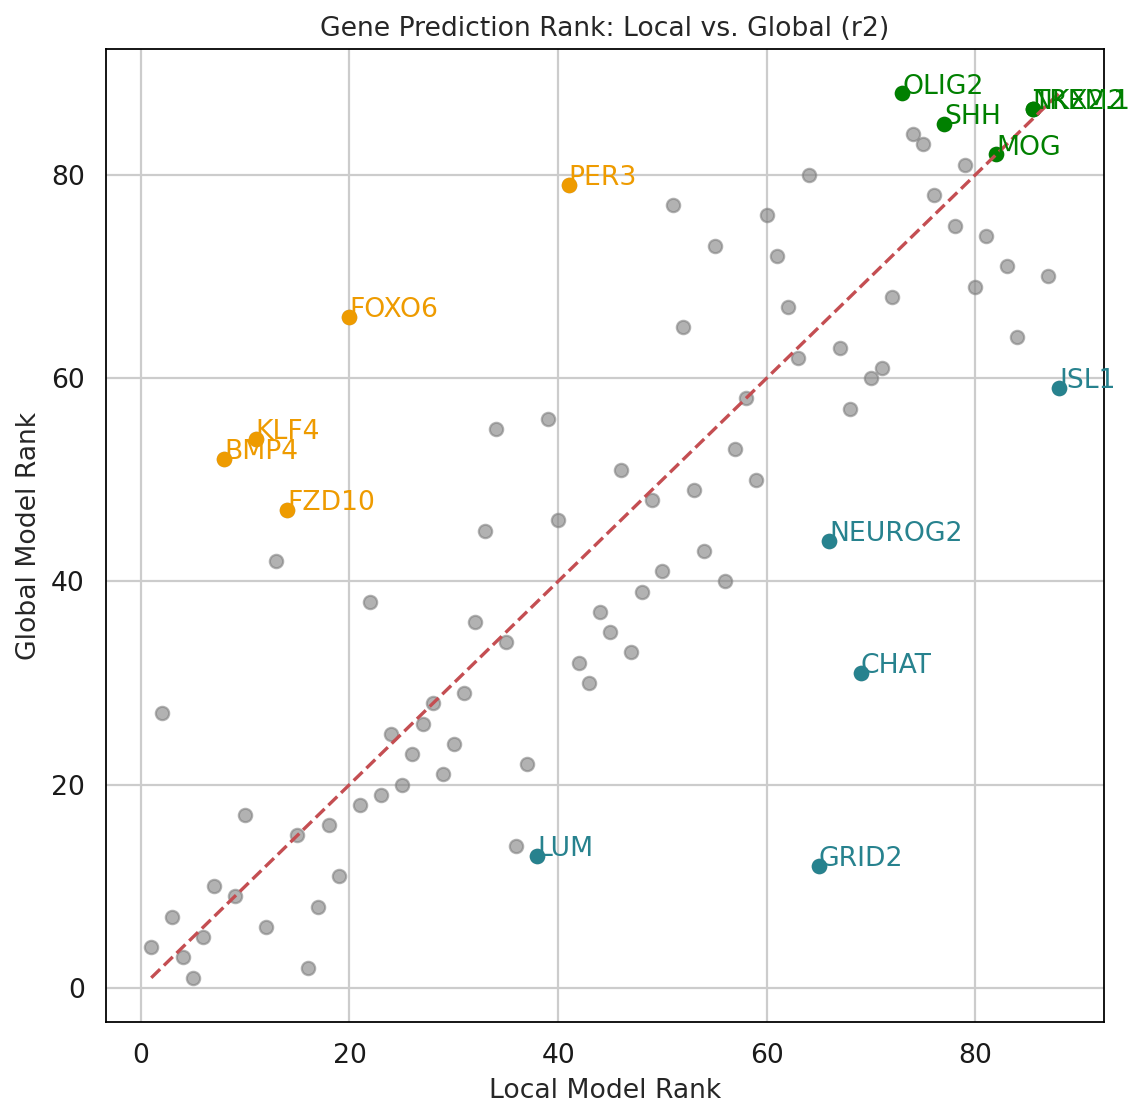

In [22]:
gene_rank_analysis(result,
                   layers_local_pred = 'combined_y_pred_local',
                   layers_global_pred = 'combined_y_pred_global',
                  color_dict=CONDITION_COLORS,
                  save_dir=FIGURE_DIR)

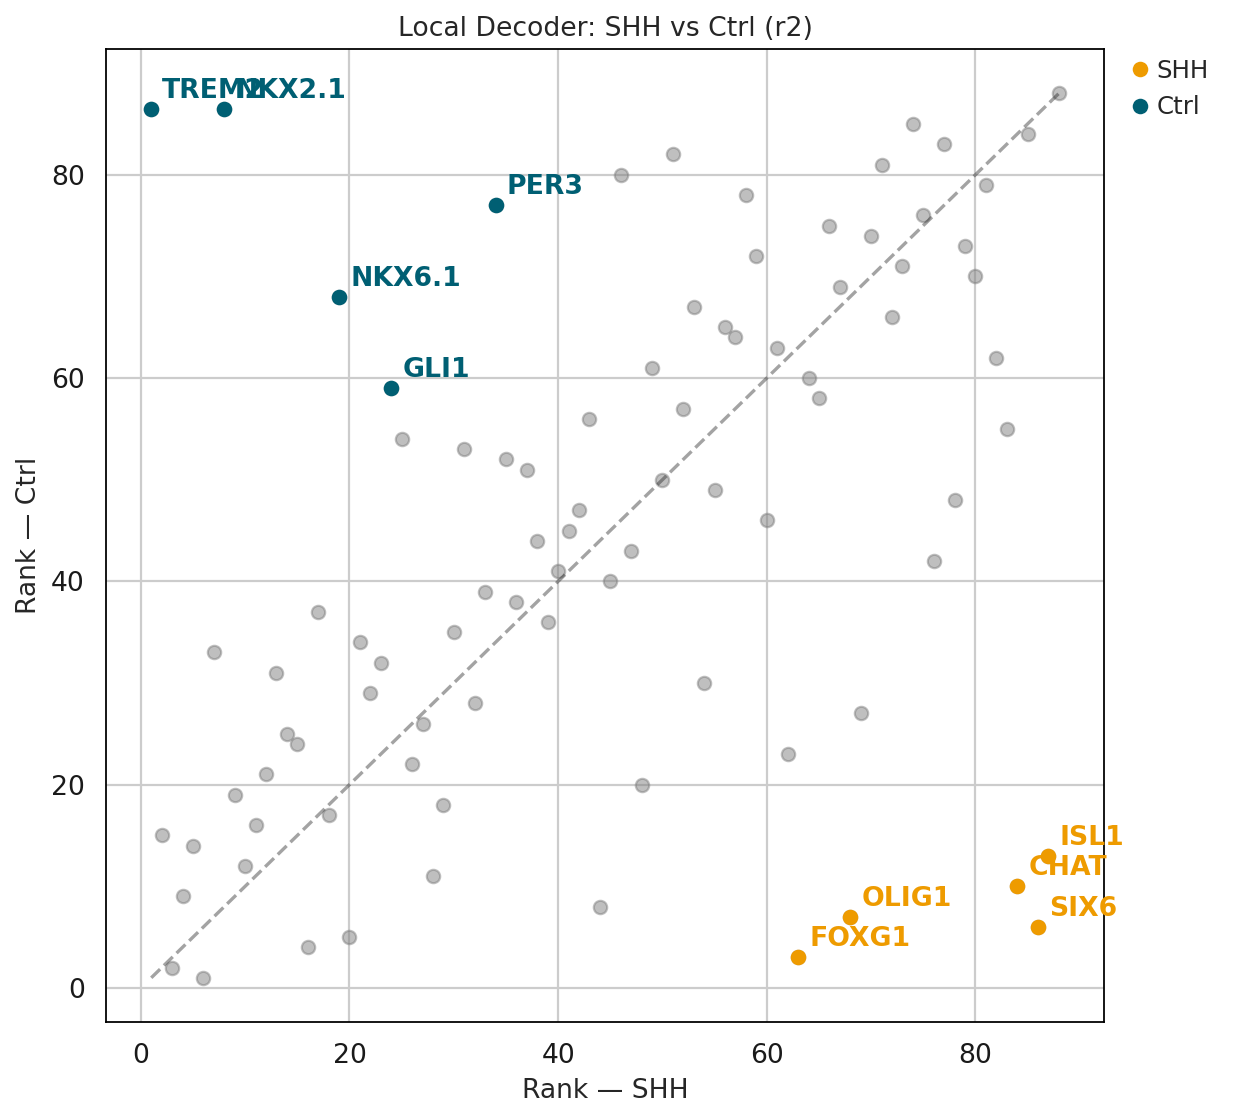

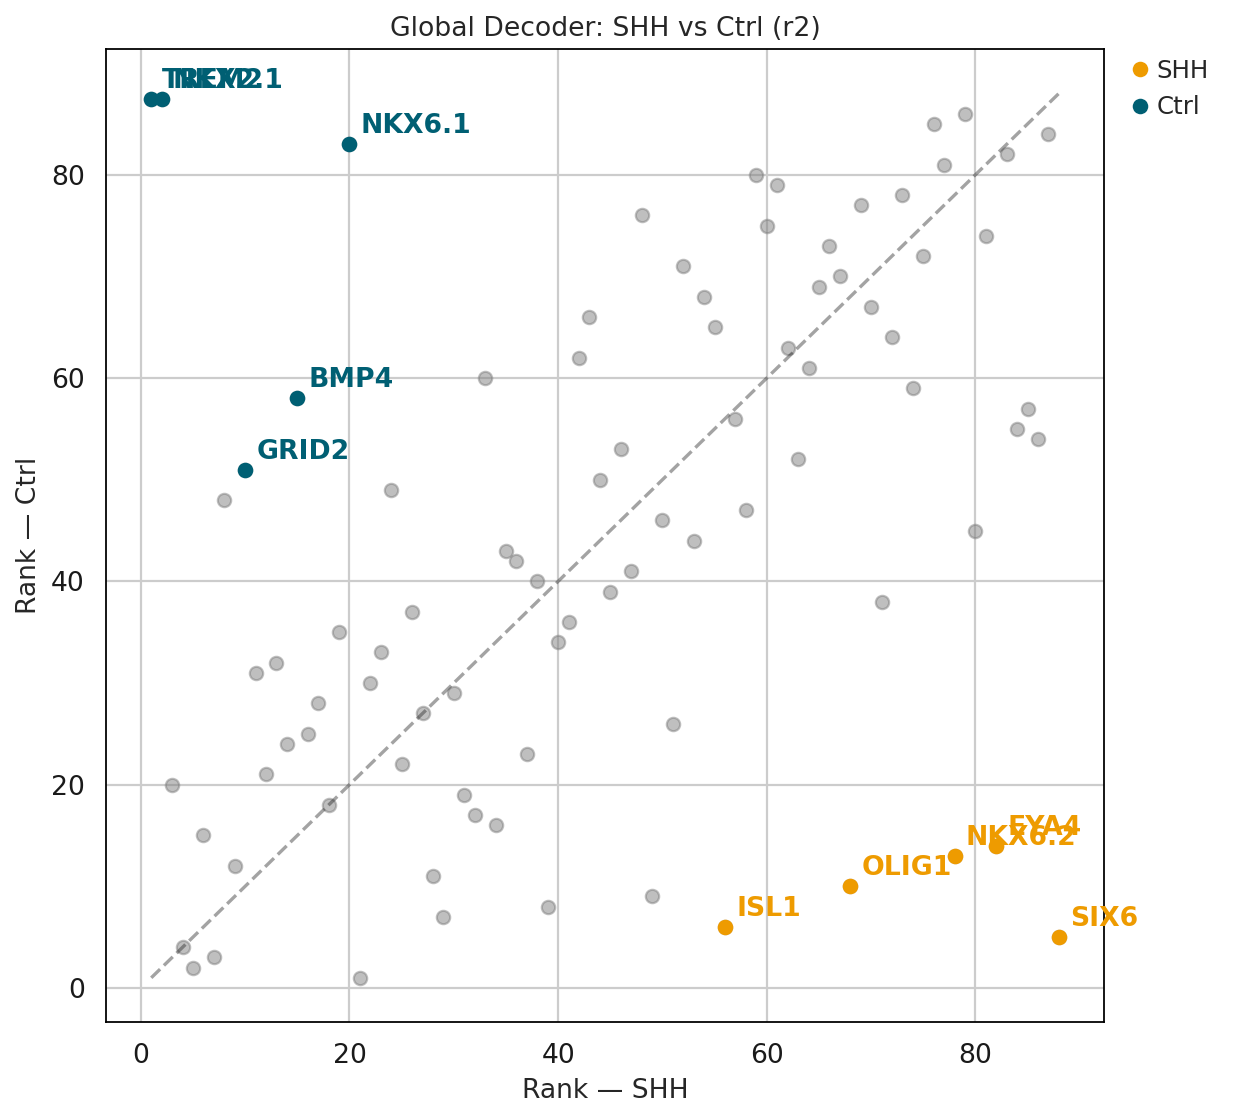

In [27]:
gene_rank_condition_comparison(result_complete,
                               library_key = "condition",
                               color_dict = CONDITION_COLORS,
                   layers_local_pred = 'combined_y_pred_local',
                   layers_global_pred = 'combined_y_pred_global')

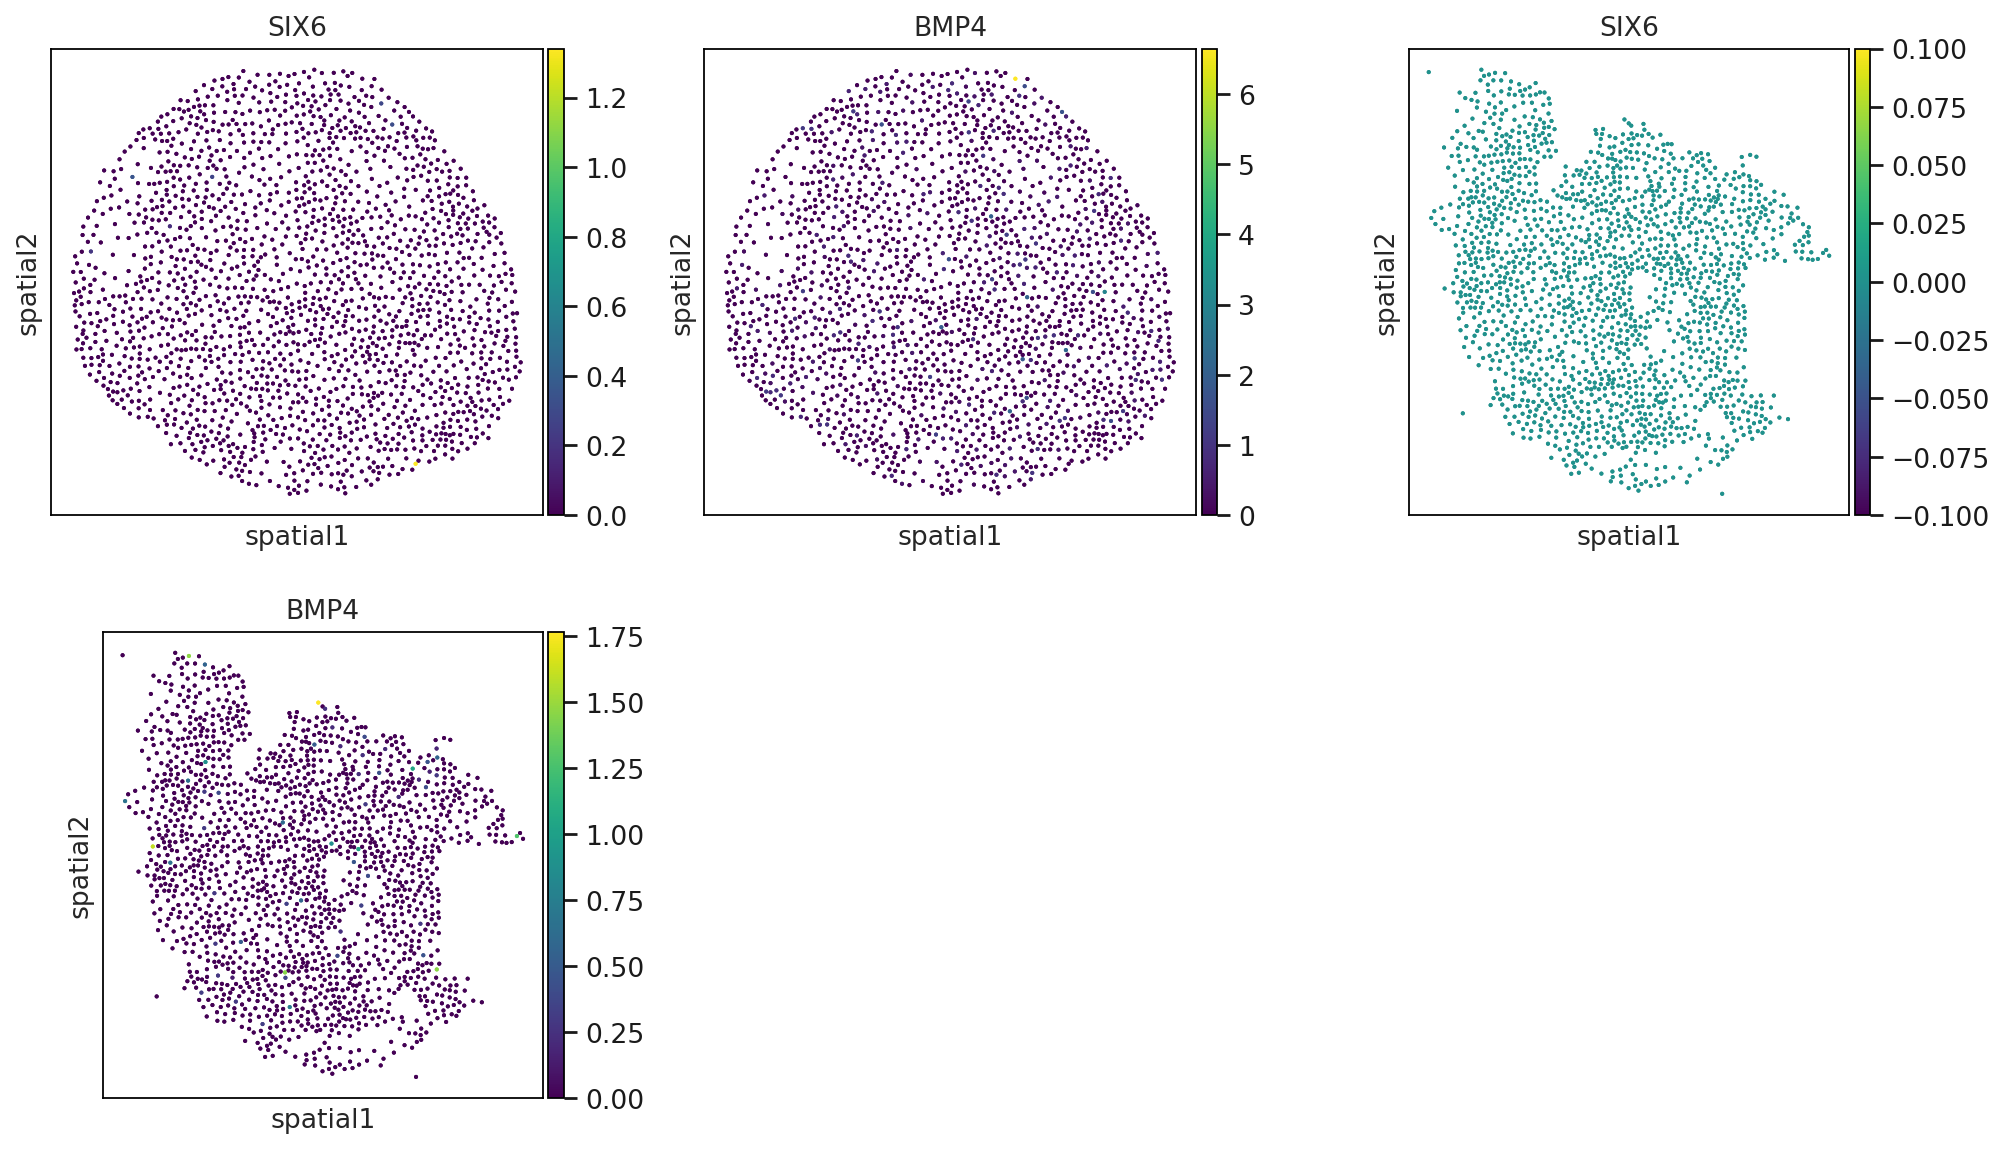

In [54]:
sq.pl.spatial_scatter(result_complete, 
                      color = ['SIX6', 'BMP4'],
                      library_key = 'sample',
                      library_id = slide_ids,
                       ncols=3,
                      cmap="viridis",
                    shape = None)

## Can we interpret the CLS token on regression trained model?

First, scale the CLS token per sliding window so that they are comparable despite their different number of cells. 

In [60]:
result_ctrl = result[result.obs['condition'] == 'Ctrl']
scale_cls_by_sample(result_ctrl, "sample")
result_shh = result[result.obs['condition'] == 'SHH']
scale_cls_by_sample(result_shh, "sample")

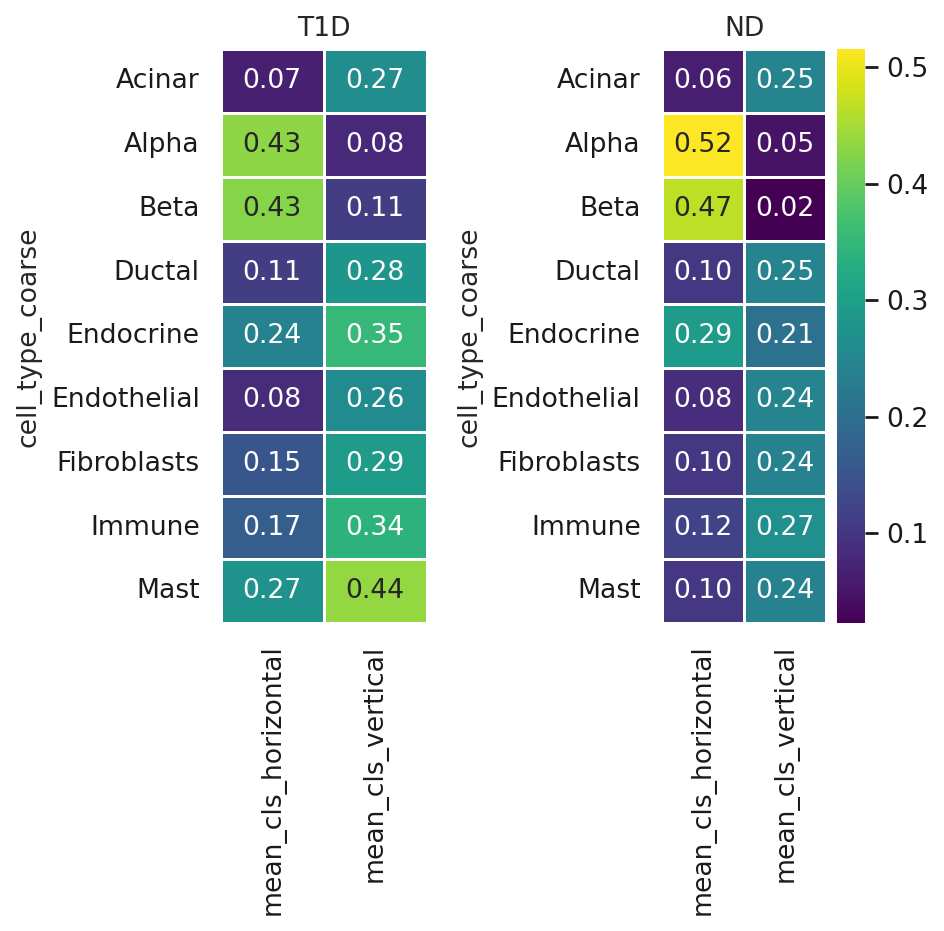

In [32]:
library_key = "cell_type_coarse"

data_shh = result_shh.obs.groupby(library_key).agg(
    mean_cls_horizontal=('combined_cls_horizontal_scaled', 'mean'),
    mean_cls_vertical=('combined_cls_vertical_scaled', 'mean')
)

data_ctrl = result_ctrl.obs.groupby(library_key).agg(
    mean_cls_horizontal=('combined_cls_horizontal_scaled', 'mean'),
    mean_cls_vertical=('combined_cls_vertical_scaled', 'mean')
)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(6, 6))

# Get min/max for shared color scale
vmin = min(data_shh.values.min(), data_ctrl.values.min())
vmax = max(data_shh.values.max(), data_ctrl.values.max())

# Plot with shared color scale
sns.heatmap(data_t1d, annot=True, linewidth=.5, fmt='.2f', 
            ax=axes[0], vmin=vmin, vmax=vmax, cbar=False, cmap = PALETTE)
axes[0].set_title('T1D')

sns.heatmap(data_nd, annot=True, linewidth=.5, fmt='.2f', 
            ax=axes[1], vmin=vmin, vmax=vmax, cmap = PALETTE)
axes[1].set_title('ND')

plt.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, f"heatmap_{library_key}.png"), dpi=300, bbox_inches='tight')
plt.show()

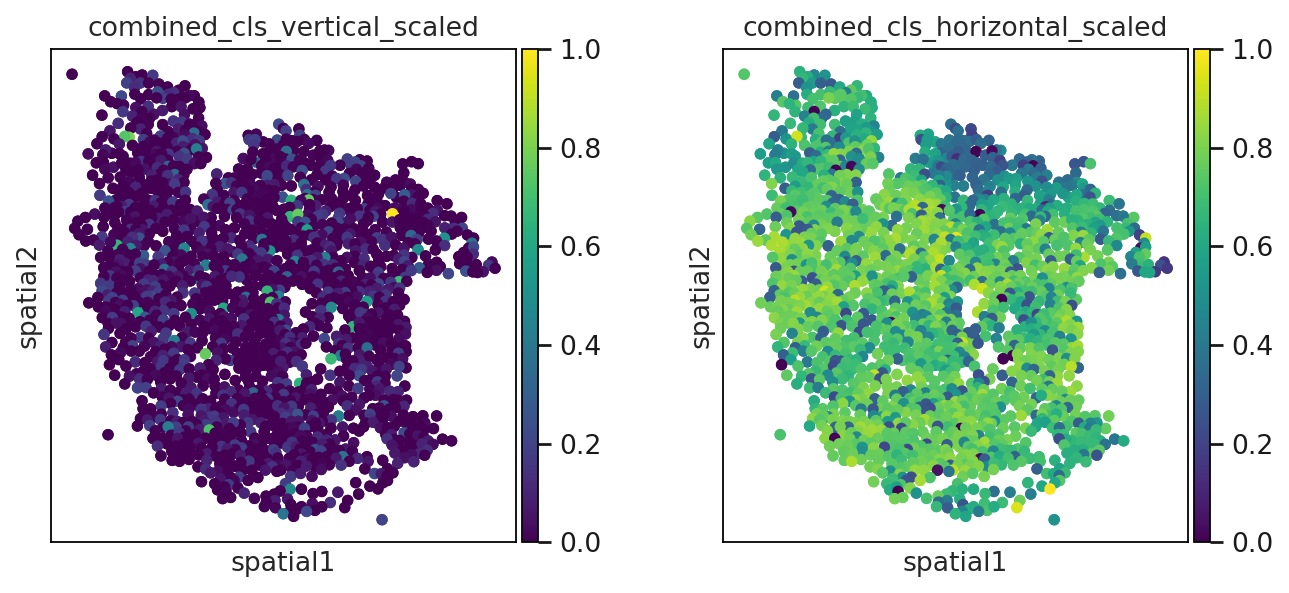

In [64]:
slide_nr = np.unique(result_nd.obs['sample'])[0]
sq.pl.spatial_scatter(result_nd, 
                      color = ['combined_cls_vertical_scaled', 'combined_cls_horizontal_scaled'],
                    cmap = PALETTE,
                    shape= None,
                      ncols = 3,
                      save = os.path.join(FIGURE_DIR, f"spatial_cls_nd_{slide_nr}.png")
)

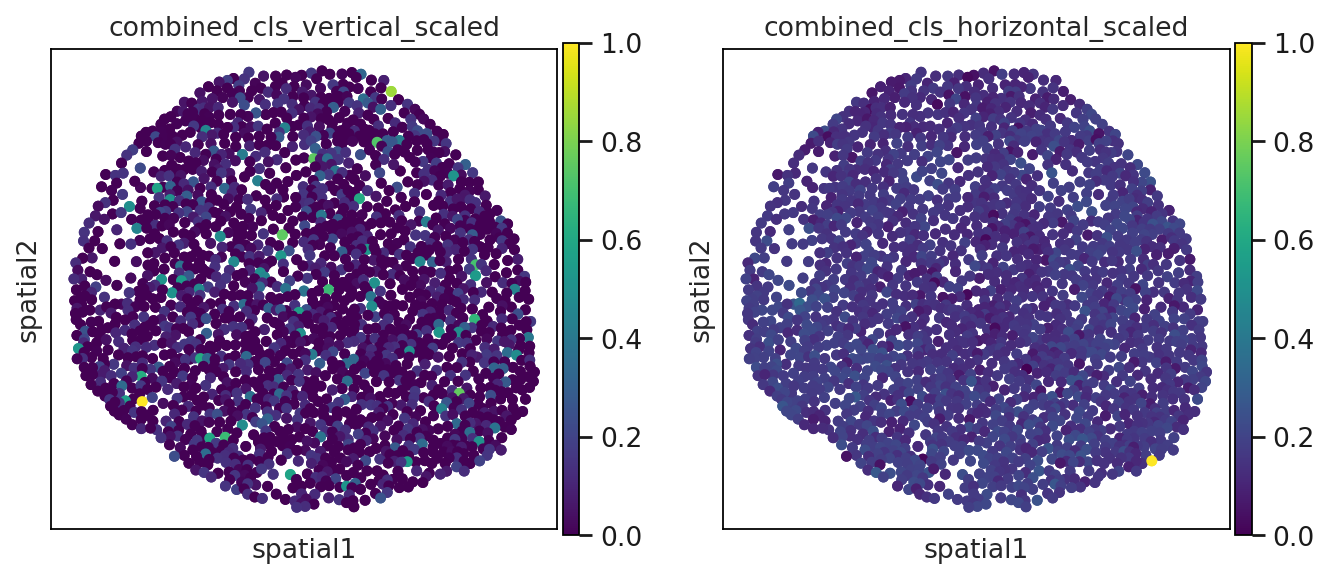

In [66]:
slide_nr = np.unique(result_t1d.obs['sample'])[0]
sq.pl.spatial_scatter(result_t1d, 
                      color = ['combined_cls_vertical_scaled', 'combined_cls_horizontal_scaled'],
                   cmap = PALETTE,
                    shape= None,
                      ncols = 3,
                      save = os.path.join(FIGURE_DIR, f"spatial_cls_t1d_{slide_nr}.png")
)